# Recyclage et territoire : à la recherche d'un profil écologique géographique ?

## Problématique

Les questions écologiques constituent une thématique importante notamment dans la gestion des territoires. Partant de ce constat, nous avons cherché un indicateur de comportement écologique que l'on pourrait croiser avec des données géographiques liés à la population francaise. Nous avons donc décidé de nous interesser à la **valorisation des déchets ménagers et assimilés (DMA)**. 

Nous allons montrer que cette valorisation n'est pas la même au sein de la France métropolitaine. En effet, les performances de valorisation varient considérablement d'un département à l'autre. Quels facteurs territoriaux et socio-économiques expliquent ces disparités ?

Ce notebook explore deux hypothèses principales :
1. **Hypothèse territoriale** : les départements ruraux, bénéficiant d'une gestion différente des déchets (compostage, valorisation organique), présenteraient de meilleurs taux de valorisation.
2. **Hypothèse socio-économique** : les départements plus aisés investiraient davantage dans les infrastructures de tri et de recyclage.

Nous nous sommes aussi intéressés aux deux composantes de la valorisation :
- ** Valorisation de la matière ** : recyclage
- ** Valorisation organique ** : compostage et méthanisation

## Données utilisées

| Source | Fichier | Description |
|--------|---------|-------------|
| ADEME / SINOE | `SINOE04_DestinationDmaParTypeTraitement.csv` | Tonnages de déchets par type de traitement et département |
| INSEE | `FET2021-19.xlsx` | Grille de densité communale (urbain/rural) |
| INSEE | `niv2021.xlsx` | Niveau de vie médian annuel par département(légèrement revu, les 3 premiers lignes ont été supprimées |

> **Reproductibilité** : les fichiers de données doivent être placés dans le même répertoire que ce notebook. Les sources sont disponibles sur [data.ademe.fr](https://data.ademe.fr) et [insee.fr](https://insee.fr).

## Plan
0. Packages et impots
1. Chargement et nettoyage des données
2. Analyse descriptive
3. Visualisations : distributions, nuages de points, cartes
4. Modélisation : corrélations et régression multiple
5. Conclusion

## 0. Quelques package necessaires : 

Installer les packages :
```bash
```

In [ ]:
!pip install requests pandas

import requests
import pandas as pd
from io import StringIO

## RECUPERATIONS DES DONNEES AVEC LES API

In [ ]:
# Cellule 3 — Récupération des données ADEME (URL directe)

ADEME_CSV_URL = (
    "https://data.ademe.fr/data-fair/api/v1/datasets/"
    "sinoe-(r)-destination-des-dma-collectes-par-type-de-traitement/"
    "data-files/SINOE04_DestinationDmaParTypeTraitement.csv"
)

def get_ademe_data():
    response = requests.get(ADEME_CSV_URL)
    response.raise_for_status()
    
    df = pd.read_csv(StringIO(response.text), sep=None, engine='python')
    print(f" fichier ADEME chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes")
    return df

df_ademe = get_ademe_data()
df_ademe.head()

✓ ADEME chargé : 14660 lignes × 10 colonnes


,ANNEE,C_REGION,L_REGION,C_DEPT,N_DEPT,C_TYP_REG_DECHET,L_TYP_REG_DECHET,C_TYP_REG_SERVICE,L_TYP_REG_SERVICE,TONNAGE_DMA
0,2009,84,Auvergne-Rhône-Alpes,01,Ain,07A,Ordures ménagères résiduelles,02B,Incinération avec récupération d'énergie,"98575,13"
1,2009,84,Auvergne-Rhône-Alpes,01,Ain,07A,Ordures ménagères résiduelles,02D,Stockage,"35633,56"
2,2009,84,Auvergne-Rhône-Alpes,01,Ain,07E,Matériaux recyclables,02A,Valorisation matière,"61734,13"
3,2009,84,Auvergne-Rhône-Alpes,01,Ain,07E,Matériaux recyclables,02E,Valorisation organique,"5460,17"
4,2009,84,Auvergne-Rhône-Alpes,01,Ain,07E,Matériaux recyclables,02B,Incinération avec récupération d'énergie,"831,58"


### DONNEES : DEPLACEMENT DOMICILE TRAVAIL

In [ ]:
# Utilisation de l'API

url = "https://api.insee.fr/melodi/data/DS_RP_NAVETTES_PRINC"

r = requests.get(url)
data = r.json()

obs = data["observations"]

df = pd.json_normalize(obs)
df = df.rename(columns={
    "dimensions.GEO":"GEO",
    "dimensions.WORK_AREA":"WORK_AREA",
    "dimensions.FREQ":"FREQ",
    "dimensions.EMPSTA_ENQ":"EMPSTA_ENQ",
    "dimensions.TIME_PERIOD":"YEAR",
    "dimensions.RP_MEASURE":"MEASURE",
    "dimensions.TRANS":"TRANS",
    "dimensions.AGE":"AGE",
    "measures.OBS_VALUE_NIVEAU.value":"VALUE"
})

df_transport= df.copy()
print(df_transport.head(5))



                 GEO WORK_AREA FREQ EMPSTA_ENQ  YEAR MEASURE TRANS     AGE  \
0  2025-BV2022-61464        _T    A          1  2022     POP     3  Y_GE15   
1  2025-BV2022-26114        10    A          1  2022     POP    _T  Y_GE15   
2  2025-BV2022-12300        10    A          1  2022     POP    _T  Y_GE15   
3  2025-BV2022-85146        _T    A          1  2022     POP     6  Y_GE15   
4  2025-BV2022-29026        10    A          1  2022     POP    _T  Y_GE15   

         VALUE  
0    59.325397  
1  1282.982125  
2  4928.760779  
3   806.168898  
4  2753.727937  


In [6]:
# ── Imports ────────────────────────────────────────────────────────────────────
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import pearsonr, spearmanr

# ── Paramètres globaux ─────────────────────────────────────────────────────────
# dpi=120 : résolution des figures (120 points par pouce, plus net que le défaut)
plt.rcParams["figure.dpi"] = 120
# whitegrid : fond blanc avec grille légère ; palette "muted" : couleurs douces
sns.set_theme(style="whitegrid", palette="muted")

# URL du fond de carte GeoJSON 
# contours des 96 départements métropolitains
# 
GEOJSON_URL = "https://france-geojson.gregoiredavid.fr/repo/departements.geojson"

print("Imports OK")

Imports OK


## 1. Chargement et nettoyage des données

### 1.1 Données SINOE (déchets)
 Le fichier SINOE recense les tonnages de DMA par département, par année
 et par **type de traitement**. Les types disponibles sont :
 - Valorisation matière ← recyclage
 - Valorisation organique ← compostage / méthanisation
 - Incinération avec/sans récupération d'énergie
 - Stockage
 - autre


In [25]:
def charger_sinoe(path: str) -> pd.DataFrame:
    """Charge et nettoie les données SINOE.
    
    Retourne un DataFrame avec une ligne par département et les colonnes :
    - tonnage_total, tonnage_valo_matiere, tonnage_valo_organique
    - taux_valo_total_pct, taux_valo_matiere_pct, taux_valo_organique_pct
    """
    # lecture du fichier csv


    df = pd.read_csv(path, sep=",", encoding="utf-8")
    print(f"Dimensions brutes : {df.shape}")
    print(f"Années disponibles : {sorted(df['ANNEE'].unique())}")
    print(f"Types de traitement : {df['L_TYP_REG_SERVICE'].unique().tolist()}")

    # Nettoyage du tonnage (virgule devient point pour python). On passe ensuite en float
    df["TONNAGE_DMA"] = (
        df["TONNAGE_DMA"]
        .astype(str)                          # s'assurer que c'est du texte
        .str.replace(",", ".", regex=False)   # "98575,13" → "98575.13"
        .astype(float)                        # conversion en nombre décimal
    )

    # Les codes département doivent être sur 2 caractères pour les jointures
    df["code_dept"]   = df["C_DEPT"].astype(str).str.zfill(2)
    df["departement"] = df["N_DEPT"]

    # Conserver la dernière année disponible
    annee_max = df["ANNEE"].max()
    df        = df[df["ANNEE"] == annee_max].copy()
    print(f"\nAnnée retenue : {annee_max}  ({len(df)} lignes après filtre)")

    # On crée des colonnes de tonnage conditionnelles AVANT le groupby.
    # where(condition, 0) : garde le tonnage si la condition est vraie, sinon met 0.
    df["tonnage_si_matiere"]   = df["TONNAGE_DMA"].where(df["est_valo_matiere"],   0)
    df["tonnage_si_organique"] = df["TONNAGE_DMA"].where(df["est_valo_organique"], 0)

    # Pour chaque département, on somme les tonnages selon leur type.
    
    dept = (
        df.groupby(["code_dept", "departement"], as_index=False)
        .agg(
            tonnage_total          = ("TONNAGE_DMA",          "sum"),
            tonnage_valo_matiere   = ("tonnage_si_matiere",   "sum"),
            tonnage_valo_organique = ("tonnage_si_organique", "sum"),
        )
    )

    # ── Calcul des taux de valorisation (en %) ───────────────────────────────────
    # Taux = tonnage valorisé / tonnage total × 100
    dept["tonnage_valo_total"]      = dept["tonnage_valo_matiere"] + dept["tonnage_valo_organique"]
    dept["taux_valo_total_pct"]     = dept["tonnage_valo_total"]    / dept["tonnage_total"] * 100
    dept["taux_valo_matiere_pct"]   = dept["tonnage_valo_matiere"]  / dept["tonnage_total"] * 100
    dept["taux_valo_organique_pct"] = dept["tonnage_valo_organique"]/ dept["tonnage_total"] * 100

    print(f"{len(dept)} départements après agrégation")
    return dept
    


# Appel de la fonction charger_sinoe
sinoe_dept = charger_sinoe("SINOE04_DestinationDmaParTypeTraitement.csv")
display(sinoe_dept.head())

Dimensions brutes : (14660, 10)
Années disponibles : [np.int64(2009), np.int64(2011), np.int64(2013), np.int64(2015), np.int64(2017), np.int64(2019), np.int64(2021)]
Types de traitement : ["Incinération avec récupération d'énergie", 'Stockage', 'Valorisation matière', 'Valorisation organique', 'Non précisé', 'Stockage pour inertes', "Incinération sans récupération d'énergie"]

Année retenue : 2021  (2004 lignes après filtre)


KeyError: 'est_valo_matiere'

### 1.2 Données FET (ruralité)

La grille de densité classe chaque commune en 4 catégories:
Commnune densément peuplée, densité intermédiaire, peu dense et très peu dense. On considère les deux dernières comme rurale.

On utilise comme indicateur la part de communes rurales dans le département.




In [26]:
def charger_ruralite(path: str) -> pd.DataFrame:
    """Charge et nettoie les données FET (grille de densité INSEE).
    
    Retourne un DataFrame à l'échelle départementale avec :
    - part_communes_rurales_pct : % de communes peu ou très peu denses
    
    Remarque : l'indicateur n'est pas pondéré par la population,
    ce qui peut surreprésenter des communes faiblement peuplées.
    """
    df = pd.read_excel(path, sheet_name="Figure 1", skiprows=2)
    # skiprows=2 : les deux premières lignes sont un en-tête inutile

    df.columns = ["code_commune", "lib_commune", "code_typologie", "lib_typologie"]

    print(f"{len(df)} communes chargées")
    print(f"Typologies : {df['lib_typologie'].unique().tolist()}")

    # Codes communes sur 5 caractères  
    df["code_commune"] = df["code_commune"].astype(str).str.zfill(5)

    # Codes département sur les 2 premiers caractères 
    df["code_dept"] = df["code_commune"].str[:2]

    # On identifie les communes rurales
    types_ruraux = ["Communes peu denses", "Communes très peu denses"]
    df["est_rural"] = df["lib_typologie"].isin(types_ruraux)

   # On agrège par département
    dept = (
        df.groupby("code_dept", as_index=False)
        .agg(
            nb_communes=("code_commune", "count"),
            nb_communes_rurales=("est_rural", "sum"),
        )
    )
    # On calcule la part des communes rurales
    dept["part_communes_rurales_pct"] = (
        dept["nb_communes_rurales"] / dept["nb_communes"] * 100
    )
    print(f"{len(dept)} départements après agrégation")
    return dept

# On appelle la fonction
    
ruralite_dept = charger_ruralite("FET2021-19.xlsx")
display(ruralite_dept.head())

34970 communes chargées
Typologies : ['Communes peu denses', 'Communes très peu denses', 'Communes de densité intermédiaire', 'Communes densément peuplées', nan]
99 départements après agrégation


,code_dept,nb_communes,nb_communes_rurales,part_communes_rurales_pct
0,01,393,328,83.460560
1,02,800,757,94.625000
2,03,317,303,95.583596
3,04,198,187,94.444444
4,05,162,157,96.913580


### 1.3 Données INSEE (niveau de vie médian)

In [27]:
def charger_niveau_vie(path: str) -> pd.DataFrame:
    """Charge et nettoie les données INSEE sur le niveau de vie médian.
    
    Retourne un DataFrame à l'échelle départementale avec :
    - niveau_vie_median : niveau de vie annuel médian en euros
    """

    # Lecture
    df = pd.read_excel(path, sheet_name="Territoire - Figure 1")
    print(f"Colonnes disponibles : {df.columns.tolist()}")
    print(f"Dimensions : {df.shape}")

    # quelques changements de nom, code_dept pour harmoniser et departement_rev 
    # pour département revenu
    df = df.rename(columns={
        "Code département": "code_dept",
        "Département": "departement_rev",
        "Niveau de vie annuel médian": "niveau_vie_median",
    })
    
    # Codes département sur les 2 premiers caractères 
    df["code_dept"] = df["code_dept"].astype(str).str.zfill(2)

    #  Conversion numérique 
    #  si une valeur n'est pas un nombre alors on l'enregistre comme NaN 
    df["niveau_vie_median"] = pd.to_numeric(df["niveau_vie_median"], errors="coerce")

    print(f"\nValeurs manquantes sur niveau_vie_median : {df['niveau_vie_median'].isna().sum()}")
    return df[["code_dept", "departement_rev", "niveau_vie_median"]]


# Appel de la fonction 
revenu_dept = charger_niveau_vie("niv2021.xlsx")
display(revenu_dept.head())

Colonnes disponibles : ['Code département', 'Département', 'Niveau de vie annuel médian']
Dimensions : (105, 3)

Valeurs manquantes sur niveau_vie_median : 4


,code_dept,departement_rev,niveau_vie_median
0,01,Ain,24810.0
1,02,Aisne,20920.0
2,03,Allier,21500.0
3,04,Alpes-de-Haute-Provence,21790.0
4,05,Hautes-Alpes,22010.0


### 1.4 Jointure des trois sources

In [29]:
# Jointures successives 
# inner join SINOE + ruralité : on ne garde que les depts présents dans les deux
# left join + revenu : on conserve tous les depts même si le revenu est manquant


df = (
    sinoe_dept
    .merge(ruralite_dept, on="code_dept", how="inner")
    .merge(revenu_dept[["code_dept", "niveau_vie_median"]], on="code_dept", how="left")
)

print(f"Table finale : {len(df)} départements")

# Terme d'interaction ruralité × niveau de vie 
# Produit des deux variables explicatives.
# Il teste si l'effet de la ruralité sur la valorisation varie selon le revenu.
# Si son coefficient est non significatif alors les deux effets sont indépendants.
df["interaction_rural_revenu"] = df["part_communes_rurales_pct"] * df["niveau_vie_median"]

display(df.head())


Table finale : 96 départements


,code_dept,departement,tonnage_total,tonnage_valo_matiere,tonnage_valo_organique,tonnage_valo_total,taux_valo_total_pct,taux_valo_matiere_pct,taux_valo_organique_pct,nb_communes,nb_communes_rurales,part_communes_rurales_pct,niveau_vie_median,interaction_rural_revenu
0,01,Ain,383489.91,139897.47,77012.73,216910.20,56.562166,36.480091,20.082075,393,328,83.460560,24810.0,2.070656e+06
1,02,Aisne,328139.23,100389.96,40931.54,141321.50,43.067542,30.593709,12.473833,800,757,94.625000,20920.0,1.979555e+06
2,03,Allier,211885.62,61220.51,30746.28,91966.79,43.403979,28.893188,14.510791,317,303,95.583596,21500.0,2.055047e+06
3,04,Alpes-de-Haute-Provence,136286.08,40255.77,15084.65,55340.42,40.606069,29.537697,11.068372,198,187,94.444444,21790.0,2.057944e+06
4,05,Hautes-Alpes,98738.31,37296.24,5164.97,42461.21,43.003784,37.772816,5.230969,162,157,96.913580,22010.0,2.133068e+06


## 2. Analyse descriptive

Avant toute modélisation, cette section présente une vue d'ensemble des trois variables principales.

In [30]:
#  Statistiques descriptives 
stats = df[cols_cles].describe().round(2)
stats.index.name = "Statistique"
display(stats)

,taux_valo_total_pct,taux_valo_matiere_pct,taux_valo_organique_pct,part_communes_rurales_pct,niveau_vie_median
Statistique,,,,,
count,96.00,96.00,96.00,96.00,96.00
mean,49.42,34.22,15.20,83.97,22706.67
std,9.78,7.16,6.96,21.79,1721.89
min,29.33,21.99,0.15,0.00,19020.00
25%,43.34,29.53,10.90,82.23,21575.00
50%,47.89,34.07,14.26,92.84,22285.00
75%,53.70,38.62,18.93,95.94,23292.50
max,87.60,65.10,33.31,99.61,29730.00


**Lecture du tableau :**
Le taux de valorisation moyen est d'environ **49 %** avec une dispersion 
importante (écart-type ~10 pts, min 29 % – max 88 %), signe de fortes 
inégalités inter-départementales.
La part de communes rurales est très élevée en moyenne (84 %), mais la 
distribution est très asymétrique : la médiane est à 93 %, ce qui reflète 
une France majoritairement rurale en nombre de communes, avec quelques 
grands départements urbains qui tirent la moyenne vers le bas (min = 0 pour 
Paris).
Le niveau de vie médian est le plus concentré des trois (std = 1722 €, 
soit ~8 % de la moyenne), ce qui limite son pouvoir discriminant dans la 
régression — les départements sont relativement homogènes sur ce plan.

In [31]:
print("Top 10 — taux de valorisation le plus élevé")
display(
    df[["code_dept", "departement",
        "taux_valo_total_pct", "taux_valo_matiere_pct", "taux_valo_organique_pct",
        "part_communes_rurales_pct"]]
    .sort_values("taux_valo_total_pct", ascending=False)
    .head(10).round(2).reset_index(drop=True)
)

print("\nTop 10 (des plus bas) — taux de valorisation le plus bas")
display(
    df[["code_dept", "departement",
        "taux_valo_total_pct", "taux_valo_matiere_pct", "taux_valo_organique_pct",
        "part_communes_rurales_pct"]]
    .sort_values("taux_valo_total_pct", ascending=True)
    .head(10).round(2).reset_index(drop=True)
)

Top 10 — taux de valorisation le plus élevé


,code_dept,departement,taux_valo_total_pct,taux_valo_matiere_pct,taux_valo_organique_pct,part_communes_rurales_pct
0,85,Vendée,87.60,65.10,22.50,93.41
1,71,Saône-et-Loire,73.28,50.48,22.80,93.98
2,64,Pyrénées-Atlantiques,72.06,38.75,33.31,89.01
3,16,Charente,71.25,42.87,28.38,95.63
4,79,Deux-Sèvres,70.23,39.15,31.08,94.92
5,17,Charente-Maritime,65.86,44.83,21.03,91.79
6,34,Hérault,65.50,33.93,31.57,77.49
7,40,Landes,65.33,37.40,27.94,94.19
8,43,Haute-Loire,62.48,47.95,14.53,94.16
9,22,Cotes-d'Armor,60.03,34.40,25.63,92.82



Top 10 (des plus bas) — taux de valorisation le plus bas


,code_dept,departement,taux_valo_total_pct,taux_valo_matiere_pct,taux_valo_organique_pct,part_communes_rurales_pct
0,75,Paris,29.33,29.18,0.15,0.00
1,93,Seine-Saint-Denis,30.25,27.07,3.18,0.00
2,94,Val-de-Marne,31.00,24.51,6.49,0.00
3,2A,Corse-du-Sud,31.11,25.33,5.78,98.39
4,92,Hauts-de-seine,32.82,30.54,2.27,0.00
5,52,Haute-Marne,35.13,24.89,10.25,98.59
6,77,Seine-et-Marne,36.03,23.48,12.56,71.99
7,95,Val-d'Oise,36.20,26.99,9.21,47.83
8,66,Pyrénées-Orientales,38.65,26.42,12.22,81.42
9,13,Bouches-du-Rhône,39.55,28.70,10.85,38.66


**Analyse :** les départements en tête de classement sont majoritairement ruraux, ce qui va dans le sens de l'hypothèse territoriale. Les derniers du classement sont souvent des départements à forte concentration urbaine.
On peut regarder ce que cela donne en séparant les deux types de valorisation.
 

In [32]:
#  valorisation MATIÈRE (recyclage) ────────────────────────────────
print("Top 10 — valorisation matière (recyclage)")
display(
    df[["code_dept", "departement", "taux_valo_matiere_pct", "taux_valo_organique_pct"]]
    .sort_values("taux_valo_matiere_pct", ascending=False)
    .head(10).round(2).reset_index(drop=True)
)

print("Top 10 les plus bas— valorisation matière (recyclage)")
display(
    df[["code_dept", "departement", "taux_valo_matiere_pct", "taux_valo_organique_pct"]]
    .sort_values("taux_valo_matiere_pct", ascending=True)
    .head(10).round(2).reset_index(drop=True)
)

#  valorisation ORGANIQUE (compostage) ─────────────────────────────
print("Top 10 — valorisation organique (compostage / méthanisation)")
display(
    df[["code_dept", "departement", "taux_valo_matiere_pct", "taux_valo_organique_pct"]]
    .sort_values("taux_valo_organique_pct", ascending=False)
    .head(10).round(2).reset_index(drop=True)
)

print("Top 10 (les plus bas)— valorisation organique (compostage / méthanisation)")
display(
    df[["code_dept", "departement", "taux_valo_matiere_pct", "taux_valo_organique_pct"]]
    .sort_values("taux_valo_organique_pct", ascending=True)
    .head(10).round(2).reset_index(drop=True)
)

Top 10 — valorisation matière (recyclage)


,code_dept,departement,taux_valo_matiere_pct,taux_valo_organique_pct
0,85,Vendée,65.10,22.50
1,24,Dordogne,51.89,5.26
2,71,Saône-et-Loire,50.48,22.80
3,43,Haute-Loire,47.95,14.53
4,48,Lozère,46.94,6.69
5,17,Charente-Maritime,44.83,21.03
6,12,Aveyron,44.20,7.78
7,39,Jura,43.61,9.32
8,16,Charente,42.87,28.38
9,70,Haute-Saône,42.74,15.64


Top 10 les plus bas— valorisation matière (recyclage)


,code_dept,departement,taux_valo_matiere_pct,taux_valo_organique_pct
0,76,Seine-Maritime,21.99,24.62
1,80,Somme,22.15,31.77
2,77,Seine-et-Marne,23.48,12.56
3,94,Val-de-Marne,24.51,6.49
4,28,Eure-et-Loir,24.83,18.59
5,52,Haute-Marne,24.89,10.25
6,90,Territoire-de-Belfort,24.92,21.69
7,41,Loir-et-Cher,25.26,18.08
8,2A,Corse-du-Sud,25.33,5.78
9,14,Calvados,25.74,21.20


Top 10 — valorisation organique (compostage / méthanisation)


,code_dept,departement,taux_valo_matiere_pct,taux_valo_organique_pct
0,64,Pyrénées-Atlantiques,38.75,33.31
1,80,Somme,22.15,31.77
2,34,Hérault,33.93,31.57
3,79,Deux-Sèvres,39.15,31.08
4,56,Morbihan,30.37,29.04
5,16,Charente,42.87,28.38
6,40,Landes,37.40,27.94
7,29,Finistère,29.81,27.60
8,22,Cotes-d'Armor,34.40,25.63
9,76,Seine-Maritime,21.99,24.62


Top 10 (les plus bas)— valorisation organique (compostage / méthanisation)


,code_dept,departement,taux_valo_matiere_pct,taux_valo_organique_pct
0,75,Paris,29.18,0.15
1,92,Hauts-de-seine,30.54,2.27
2,93,Seine-Saint-Denis,27.07,3.18
3,23,Creuse,40.16,3.29
4,05,Hautes-Alpes,37.77,5.23
5,24,Dordogne,51.89,5.26
6,2A,Corse-du-Sud,25.33,5.78
7,32,Gers,41.89,5.96
8,94,Val-de-Marne,24.51,6.49
9,69,Rhône,34.97,6.62


## 3. Visualisations

### 3.1 Distributions des variables

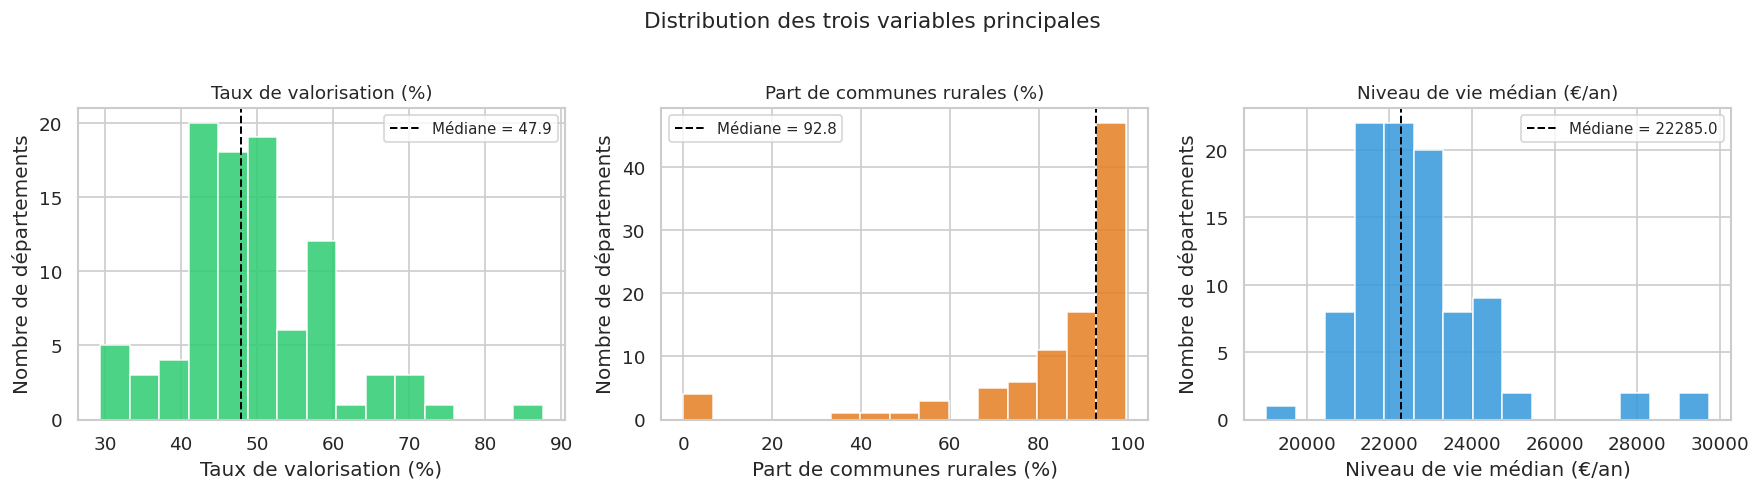

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

vars_labels = [
    ("taux_valorisation_pct",     "Taux de valorisation (%)",       "#2ecc71"),
    ("part_communes_rurales_pct", "Part de communes rurales (%)",   "#e67e22"),
    ("niveau_vie_median",          "Niveau de vie médian (€/an)",   "#3498db"),
]

for ax, (col, label, color) in zip(axes, vars_labels):
    ax.hist(df[col].dropna(), bins=15, color=color, edgecolor="white", alpha=0.85)
    med = df[col].median()
    ax.axvline(med, color="black", linestyle="--", linewidth=1.2, label=f"Médiane = {med:.1f}")
    ax.set_title(label, fontsize=11)
    ax.set_xlabel(label)
    ax.set_ylabel("Nombre de départements")
    ax.legend(fontsize=9)

plt.suptitle("Distribution des trois variables principales", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Lecture :** La distribution du taux de valorisation est relativement symétrique autour de la médiane. La ruralité présente une distribution bimodale (départements très ruraux vs. très urbains), ce qui pourra générer une relation non-linéaire avec la valorisation. Le niveau de vie médian est quant à lui concentré autour d'une plage relativement étroite, avec quelques départements à fort revenu.

### 3.2 Nuages de points : ruralité, niveau de vie et valorisation

In [39]:
def scatter_regression(ax, x_col, y_col,x_label, y_label, color, n_outliers=3):
    """Nuage de points avec droite de régression et annotation des outliers.
    Les outliers annotés sont les départements dont l'écart à la droite de
    régression (résidu) est le plus grand en valeur absolue."""
    
    # Suppression des lignes avec valeurs manquantes
    tmp = df[[x_col, y_col, "departement"]].dropna()

    # Nuage de points
    ax.scatter(tmp[x_col], tmp[y_col], alpha=0.6, color=color, edgecolors="white", s=50)

    # Calcul et tracé de la droite de régression (degré 1 = linéaire)
    pente, ordonnee = np.polyfit(tmp[x_col], tmp[y_col], 1)
    x_range = np.linspace(tmp[x_col].min(), tmp[x_col].max(), 100)
    ax.plot(x_range, pente * x_range + ordonnee,
            "k--", linewidth=1.5, label="Régression linéaire")


    # Annotation des 3 outliers les plus éloignés de la droite
    residus = tmp[y_col] - (pente * tmp[x_col] + ordonnee)
    outliers = residus.abs().nlargest(n_outliers).index
    for idx in outliers:
        ax.annotate(
            tmp.loc[idx, "departement"],
            xy=(tmp.loc[idx, x_col], tmp.loc[idx, y_col]),
            fontsize=7, xytext=(4, 4), textcoords="offset points"
        )

    # Corrélation de Pearson affichée avec le titre
    r, p = pearsonr(tmp[x_col], tmp[y_col])
    ax.set_title(f"{y_label} ~ {x_label}\nr = {r:.3f}  (p = {p:.4f})", fontsize=9)
    ax.legend(fontsize=8)


TypeError: scatter_regression() missing 2 required positional arguments: 'y_label' and 'color'

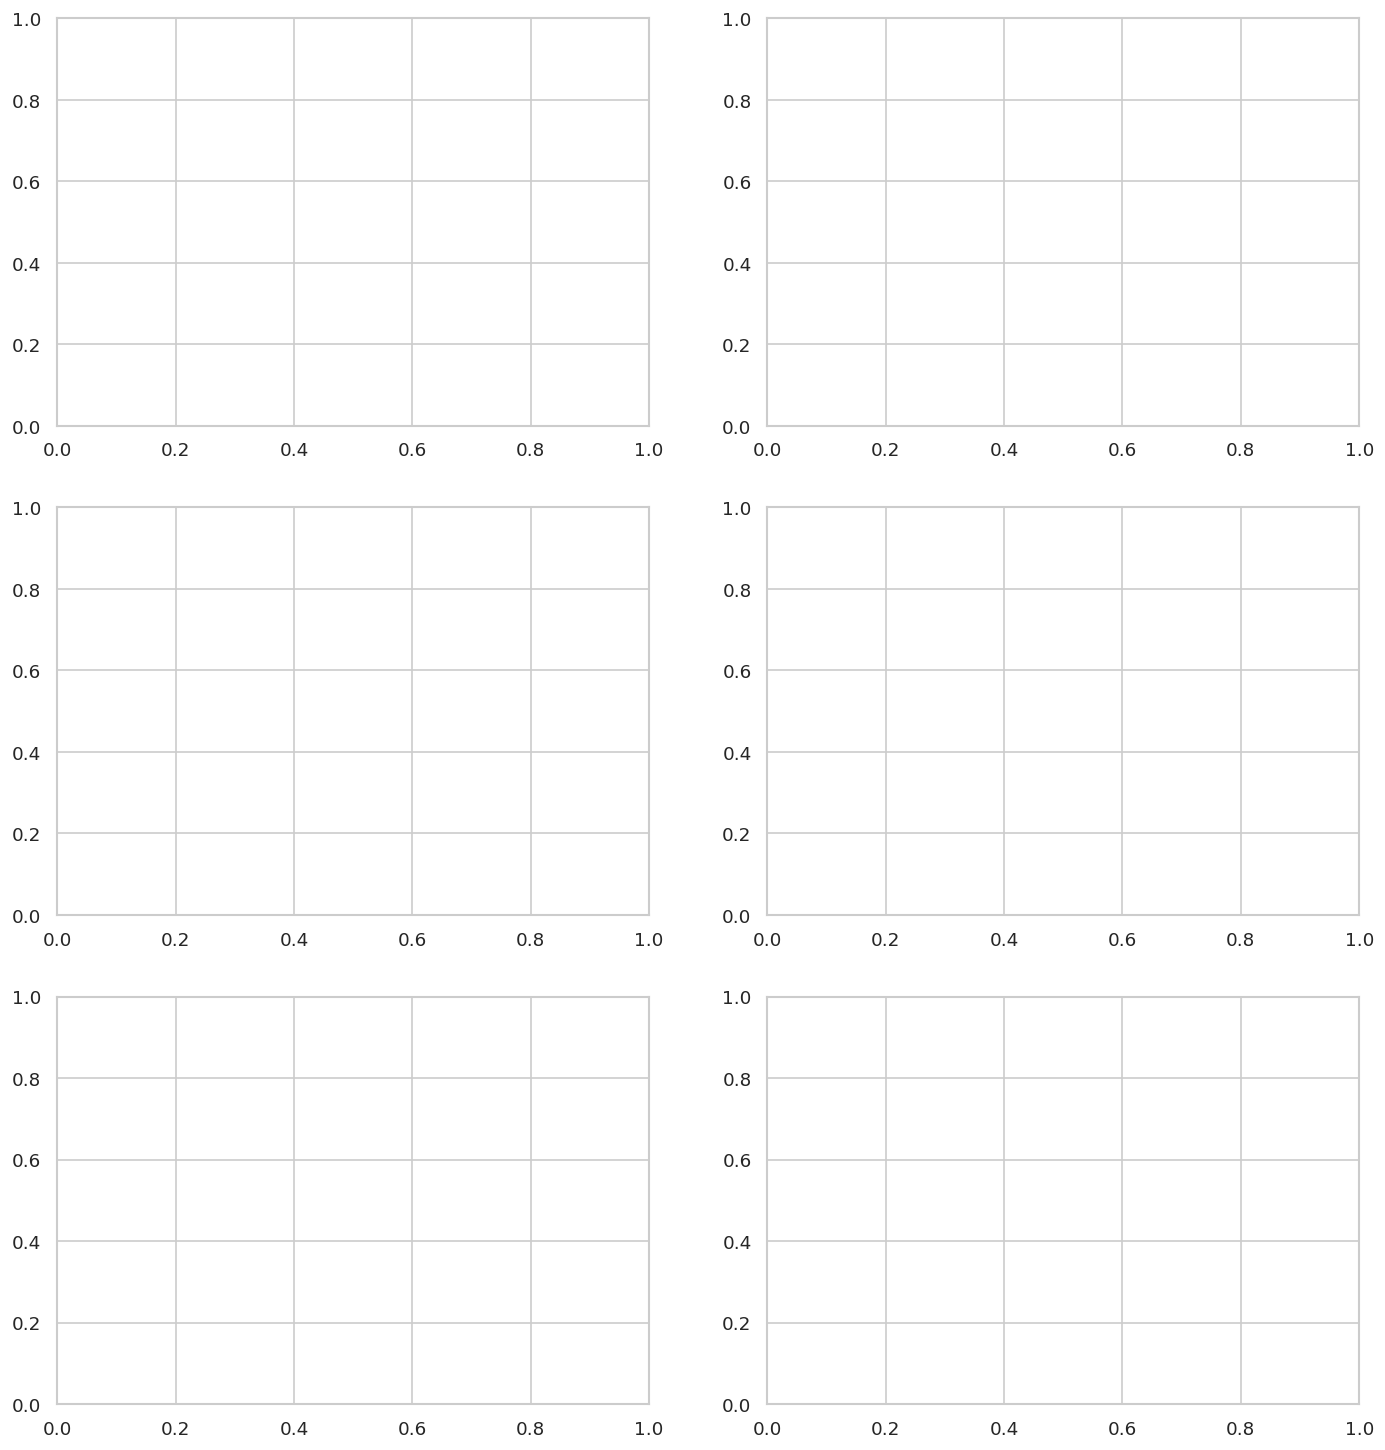

In [40]:
# Grille 3×2 : 3 indicateurs × 2 variables explicatives 
# Lignes : valorisation totale / matière / organique
# Colonnes : ruralité / niveau de vie

import numpy as np

fig, axes = plt.subplots(3, 2, figsize=(14, 15))

lignes = [
    ("taux_valo_total_pct",     "Valorisation totale (%)"),
    ("taux_valo_matiere_pct",   "Valorisation matière (%)"),
    ("taux_valo_organique_pct", "Valorisation organique (%)"),
]
colonnes = [
    ("part_communes_rurales_pct", "Part de communes rurales (%)", "#e67e22"),
    ("niveau_vie_median",          "Niveau de vie médian (€/an)", "#3498db"),
]

for i, (y_col, y_label) in enumerate(lignes):
    for j, (x_col, x_label, color) in enumerate(colonnes):
        scatter_regression(axes[i][j], x_col, y_col, color)
        axes[i][j].set_xlabel(x_label)
        axes[i][j].set_ylabel(y_label)

plt.suptitle("Relations bivariées : ruralité & niveau de vie vs. valorisation",
             fontsize=13)
plt.tight_layout()
plt.show()



**Analsye :**
- **Ruralité (gauche)** : la droite de régression est  ascendante, confirmant une relation positive entre part de communes rurales et taux de valorisation. Le coefficient de corrélation de Pearson est modéré mais significatif. Cela se retrouve aussi bien pour le total que por les deux types de valorisation.
- **Niveau de vie (droite)** : la pente est quasi-nulle et la p-value dépasse le seuil de 5 %. Il n'y a pas de relation linéaire claire entre le revenu médian et la valorisation des déchets à l'échelle départementale.
- Les départements annotés (outliers) sont ceux dont les résidus sont les plus importants, c'est-à-dire ceux dont le comportement s'écarte le plus de la tendance générale — ils méritent une attention particulière.

### 3.3 Heatmap de corrélation


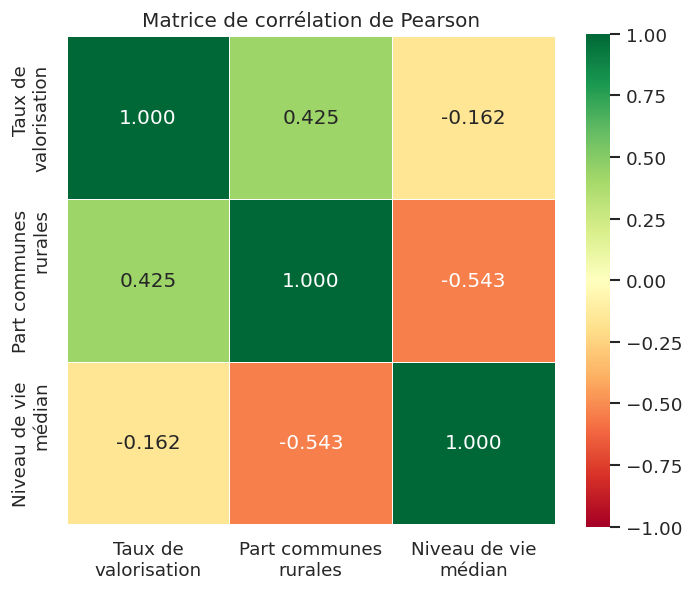

In [ ]:
vars_corr = ["taux_valorisation_pct", "part_communes_rurales_pct", "niveau_vie_median"]
labels_corr = ["Taux de\nvalorisation", "Part communes\nrurales", "Niveau de vie\nmédian"]

mat_corr = df[vars_corr].corr().round(3)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    mat_corr,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    vmin=-1, vmax=1,
    xticklabels=labels_corr,
    yticklabels=labels_corr,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Matrice de corrélation de Pearson", fontsize=12)
plt.tight_layout()
plt.show()

**Lecture :** La heatmap confirme que la corrélation la plus forte avec le taux de valorisation est celle de la ruralité (valeur positive modérée). On note également une corrélation négative entre ruralité et niveau de vie — les départements ruraux sont en moyenne moins riches — ce qui soulève un risque de **colinéarité partielle** entre les deux variables explicatives. Ce point sera discuté dans la régression multiple.

### 3.4 Analyse cartographique

Les cartes permettent de donner une dimension géographique à l'analyse statistique.

In [ ]:
def charger_carte(df_data: pd.DataFrame) -> gpd.GeoDataFrame:
    """Charge le fond de carte et y joint les données départementales."""
    carte = gpd.read_file(GEOJSON_URL)
    carte["code"] = carte["code"].astype(str).str.zfill(2)
    df_data["code_dept"] = df_data["code_dept"].astype(str).str.zfill(2)
    return carte.merge(df_data, left_on="code", right_on="code_dept", how="left")


carte = charger_carte(df)
print("Carte chargée :", len(carte), "départements")

Carte chargée : 96 départements


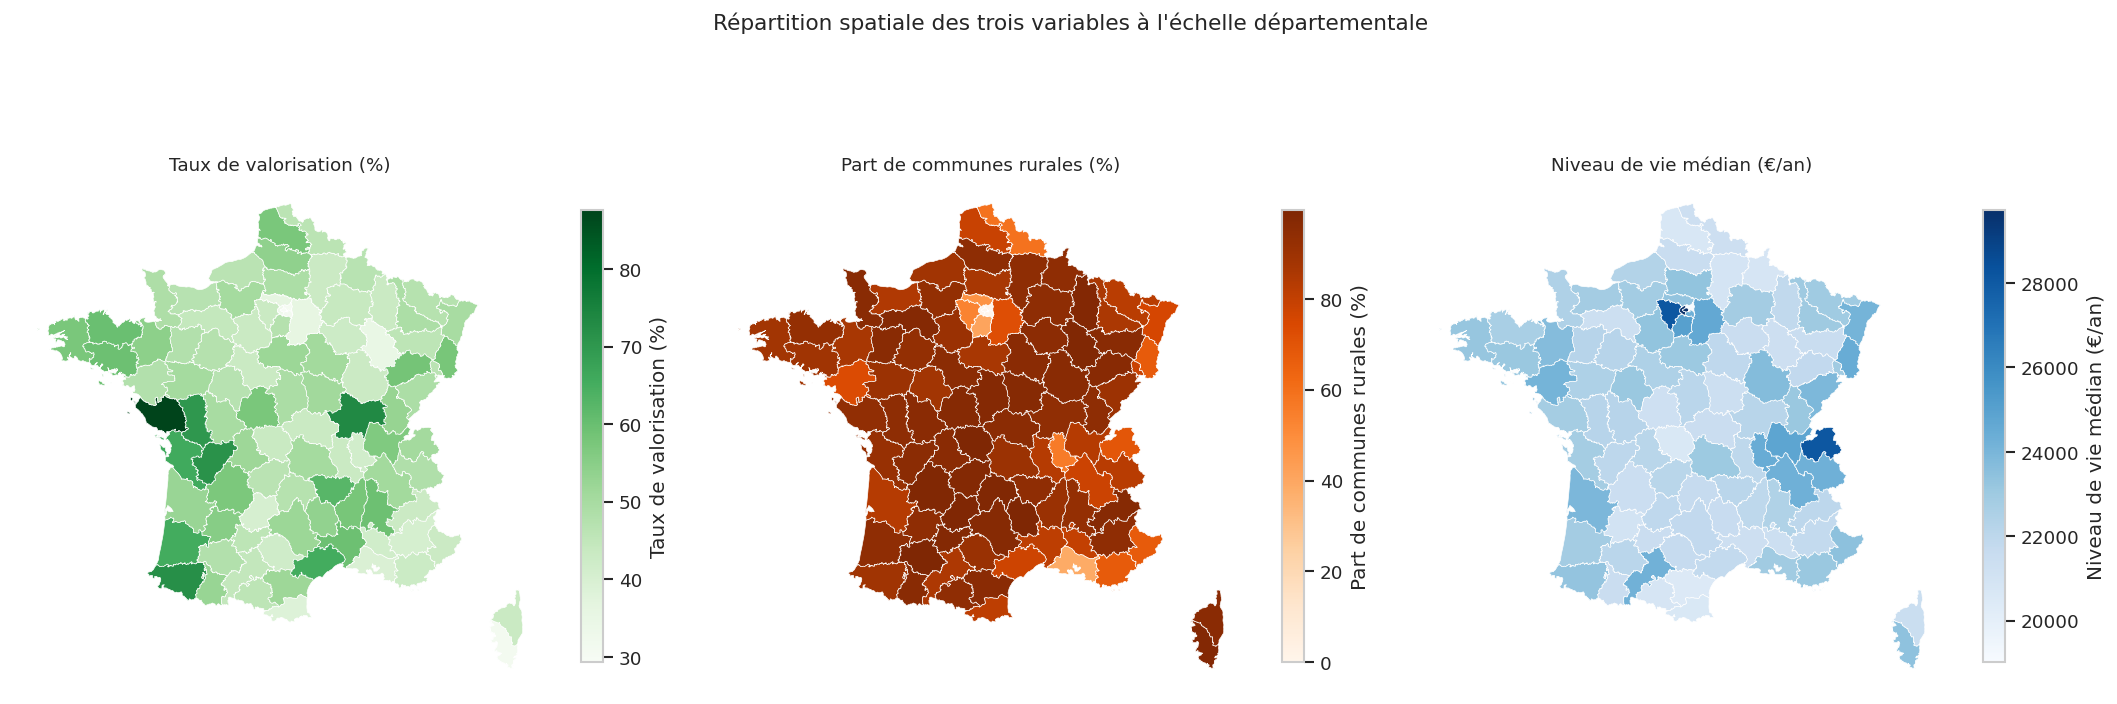

In [ ]:
# ── Cartes choroplèthes : 3 variables côte à côte ─────────────────────────────
configs = [
    ("taux_valorisation_pct",     "Greens",  "Taux de valorisation (%)"),
    ("part_communes_rurales_pct", "Oranges", "Part de communes rurales (%)"),
    ("niveau_vie_median",          "Blues",   "Niveau de vie médian (€/an)"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, (col, cmap, title) in zip(axes, configs):
    carte.plot(
        column=col,
        cmap=cmap,
        linewidth=0.4,
        edgecolor="white",
        legend=True,
        legend_kwds={"shrink": 0.6, "label": title},
        ax=ax,
        missing_kwds={"color": "lightgrey", "label": "Donnée manquante"}
    )
    ax.set_title(title, fontsize=11)
    ax.axis("off")

plt.suptitle("Répartition spatiale des trois variables à l'échelle départementale", fontsize=13)
plt.tight_layout()
plt.show()

**Lecture des cartes :**
- La carte de valorisation (verte) révèle une **concentration des bons performeurs dans les zones rurales** (diagonale nord-est / sud-ouest et Massif Central), alors que les grandes métropoles et leurs couronnes affichent des taux plus faibles.
- La carte de ruralité (orange) montre une structure spatiale similaire, ce qui renforce visuellement la corrélation positive entre les deux variables.
- La carte de niveau de vie (bleue) présente un gradient différent, plus concentré autour de l'Île-de-France et de quelques métropoles. Sa géographie est donc **distincte** de celle de la valorisation, cohérent avec l'absence de corrélation significative observée statistiquement.

In [ ]:
# ── Carte typologique : 4 profils territoriaux ────────────────────────────────
med_valo  = df["taux_valorisation_pct"].median()
med_rural = df["part_communes_rurales_pct"].median()
med_rev   = df["niveau_vie_median"].median()

print(f"Médianes — valorisation : {med_valo:.1f}% | ruralité : {med_rural:.1f}% | revenu : {med_rev:.0f} €")

def profil_territorial(row):
    valo  = row["taux_valorisation_pct"] >= med_valo
    rural = row["part_communes_rurales_pct"] >= med_rural
    if   not rural and not valo: return "Urbain / valorisation faible"
    elif not rural and valo:     return "Urbain / valorisation forte"
    elif rural and not valo:     return "Rural / valorisation faible"
    else:                        return "Rural / valorisation forte"

ordre = [
    "Urbain / valorisation faible",
    "Urbain / valorisation forte",
    "Rural / valorisation faible",
    "Rural / valorisation forte",
]
couleurs = {
    "Urbain / valorisation faible": "#f4a3a3",
    "Urbain / valorisation forte":  "#a8ddb5",
    "Rural / valorisation faible":  "#b30000",
    "Rural / valorisation forte":   "#006d2c",
}

df["profil"] = pd.Categorical(
    df.apply(profil_territorial, axis=1), categories=ordre, ordered=True
)

print("\nRépartition des profils :")
display(df["profil"].value_counts().rename("Nombre de départements").to_frame())

Médianes — valorisation : 47.9% | ruralité : 92.8% | revenu : 22285 €

Répartition des profils :


,Nombre de départements
profil,
Urbain / valorisation faible,25
Rural / valorisation forte,25
Urbain / valorisation forte,23
Rural / valorisation faible,23


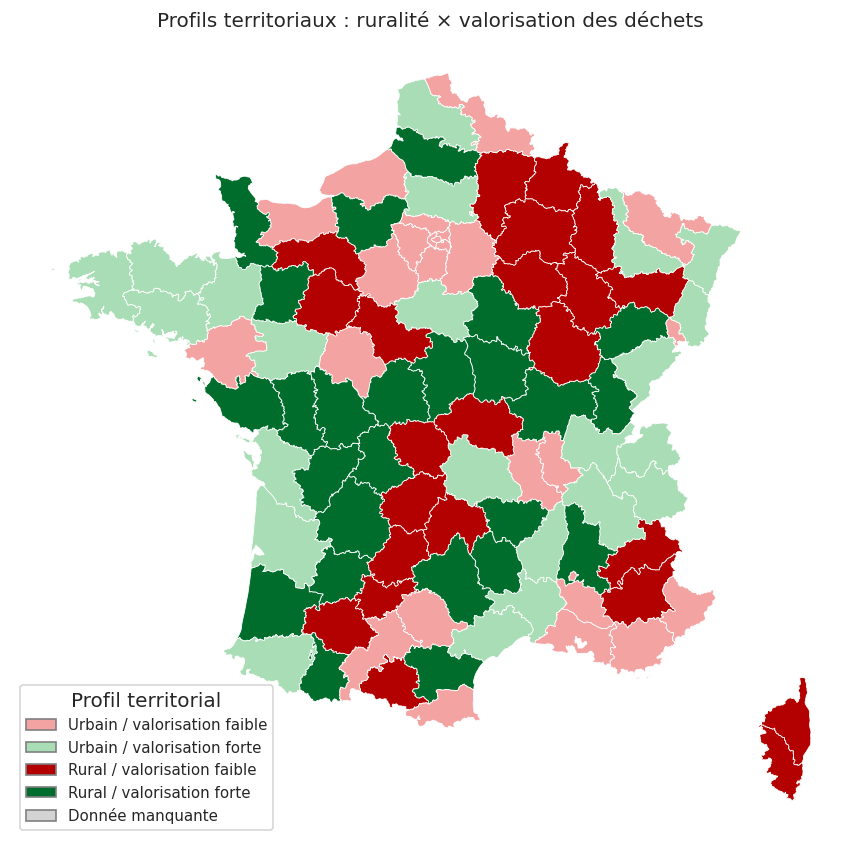

In [ ]:
carte2 = charger_carte(df)
carte2["couleur"] = carte2["profil"].map(couleurs)

fig, ax = plt.subplots(figsize=(9, 10))
carte2.plot(
    color=carte2["couleur"].astype(object).fillna("lightgrey"),
    linewidth=0.5, edgecolor="white", ax=ax
)

legend_patches = [
    mpatches.Patch(facecolor=v, edgecolor="grey", label=k)
    for k, v in couleurs.items()
] + [mpatches.Patch(facecolor="lightgrey", edgecolor="grey", label="Donnée manquante")]

ax.legend(handles=legend_patches, title="Profil territorial",
          loc="lower left", frameon=True, fontsize=9)
ax.set_title("Profils territoriaux : ruralité × valorisation des déchets", fontsize=12)
ax.axis("off")
plt.show()

**Lecture :** La carte typologique fait ressortir une concentration des profils **« rural / valorisation forte »** (vert foncé) dans les zones à forte tradition agricole et rurale (Massif Central, Bretagne intérieure, etc.). Les profils **« rural / valorisation faible »** (rouge foncé) constituent des cas d'exception à analyser : ils indiquent que la ruralité seule n'est pas une garantie de bonne performance, et que d'autres facteurs (organisation des filières, équipements) jouent un rôle.

## 4. Modélisation

### 4.1 Corrélations bivariées

In [ ]:
def afficher_correlations(df, var1, var2, label1, label2):
    """Calcule et affiche les corrélations de Pearson et Spearman."""
    tmp = df[[var1, var2]].dropna()
    r_p, p_p = pearsonr(tmp[var1], tmp[var2])
    r_s, p_s = spearmanr(tmp[var1], tmp[var2])
    print(f"  {label1} × {label2}")
    print(f"  Pearson  r = {r_p:.3f}  (p = {p_p:.10f})")
    print(f"  Spearman ρ = {r_s:.3f}  (p = {p_s:.10f})")
    sig = "✅ significatif" if p_p < 0.05 else "❌ non significatif"
    print(f"  → {sig} au seuil 5 %\n")


afficher_correlations(df, "part_communes_rurales_pct", "taux_valorisation_pct",
                      "Ruralité", "Valorisation")
afficher_correlations(df, "niveau_vie_median", "taux_valorisation_pct",
                      "Niveau de vie", "Valorisation")
afficher_correlations(df, "part_communes_rurales_pct", "niveau_vie_median",
                      "Ruralité", "Niveau de vie")

  Ruralité × Valorisation
  Pearson  r = 0.425  (p = 0.0000161464)
  Spearman ρ = 0.139  (p = 0.1772026465)
  → ✅ significatif au seuil 5 %

  Niveau de vie × Valorisation
  Pearson  r = -0.162  (p = 0.1151794970)
  Spearman ρ = -0.028  (p = 0.7847314422)
  → ❌ non significatif au seuil 5 %

  Ruralité × Niveau de vie
  Pearson  r = -0.543  (p = 0.0000000106)
  Spearman ρ = -0.543  (p = 0.0000000110)
  → ✅ significatif au seuil 5 %



**Interprétation :** La ruralité est significativement corrélée à la valorisation (Pearson et Spearman concordants). Le niveau de vie ne l'est pas. On note également que ruralité et niveau de vie sont négativement corrélés : les territoires ruraux ont tendance à être moins riches. Cette structure de corrélation sera à surveiller dans la régression multiple.

⚠️ **Point d'attention Pour ruralité x Valorisation** : la corrélation de Pearson (r = 0.425, p < 0.001) 
et celle de Spearman (ρ = 0.139, p = 0.177) donnent des conclusions 
opposées. Cela s'explique par la forme de la relation : Pearson capte 
l'association linéaire, Spearman l'association monotone sur les rangs.

La distribution très asymétrique de la ruralité (beaucoup de départements 
à > 90 %, quelques-uns à 0 %) crée des cas extrêmes qui "gonflent" le r 
de Pearson. Le résultat de Spearman invite à la prudence : la relation 
n'est pas robuste sur l'ensemble de la distribution. C'est une raison 
supplémentaire pour interpréter le modèle de régression avec nuance.

### 4.2 Régression linéaire multiple avec terme d'interaction

On estime trois modèles emboîtés pour évaluer l'apport de chaque variable :
- **Modèle 1** : ruralité seule
- **Modèle 2** : ruralité + niveau de vie
- **Modèle 3** : ruralité + niveau de vie + **terme d'interaction** (ruralité × niveau de vie, centré)

Le terme d'interaction teste si l'effet de la ruralité sur la valorisation **varie selon le niveau de richesse du département**.

In [ ]:
tmp = df[["taux_valorisation_pct", "part_communes_rurales_pct",
          "niveau_vie_median", "interaction_rural_revenu"]].dropna()

y = tmp["taux_valorisation_pct"]

# Modèle 1 : ruralité seule
X1 = sm.add_constant(tmp[["part_communes_rurales_pct"]])
mod1 = sm.OLS(y, X1).fit()

# Modèle 2 : ruralité + niveau de vie
X2 = sm.add_constant(tmp[["part_communes_rurales_pct", "niveau_vie_median"]])
mod2 = sm.OLS(y, X2).fit()

# Modèle 3 : ruralité + niveau de vie + interaction (variables centrées)
X3 = sm.add_constant(tmp[["part_communes_rurales_pct", "niveau_vie_median", "interaction_rural_revenu"]])
mod3 = sm.OLS(y, X3).fit()

# Tableau de synthèse
synthese = pd.DataFrame({
    "Modèle 1 (ruralité)": [
        f"{mod1.params['part_communes_rurales_pct']:.3f} ({'*' if mod1.pvalues['part_communes_rurales_pct']<0.05 else 'ns'})",
        "—", "—", f"{mod1.rsquared:.3f}", f"{mod1.rsquared_adj:.3f}", f"{mod1.fvalue:.2f} (p={mod1.f_pvalue:.4f})"
    ],
    "Modèle 2 (+revenu)": [
        f"{mod2.params['part_communes_rurales_pct']:.3f} ({'*' if mod2.pvalues['part_communes_rurales_pct']<0.05 else 'ns'})",
        f"{mod2.params['niveau_vie_median']:.4f} ({'*' if mod2.pvalues['niveau_vie_median']<0.05 else 'ns'})",
        "—", f"{mod2.rsquared:.3f}", f"{mod2.rsquared_adj:.3f}", f"{mod2.fvalue:.2f} (p={mod2.f_pvalue:.4f})"
    ],
    "Modèle 3 (+interaction)": [
        f"{mod3.params['part_communes_rurales_pct']:.3f} ({'*' if mod3.pvalues['part_communes_rurales_pct']<0.05 else 'ns'})",
        f"{mod3.params['niveau_vie_median']:.4f} ({'*' if mod3.pvalues['niveau_vie_median']<0.05 else 'ns'})",
        f"{mod3.params['interaction_rural_revenu']:.5f} ({'*' if mod3.pvalues['interaction_rural_revenu']<0.05 else 'ns'})",
        f"{mod3.rsquared:.3f}", f"{mod3.rsquared_adj:.3f}", f"{mod3.fvalue:.2f} (p={mod3.f_pvalue:.4f})"
    ]
}, index=["Part communes rurales", "Niveau de vie médian", "Interaction (centré)",
          "R²", "R² ajusté", "F-stat"])

display(synthese)
print("\n* = significatif à 5 % | ns = non significatif")

,Modèle 1 (ruralité),Modèle 2 (+revenu),Modèle 3 (+interaction)
Part communes rurales,0.191 (*),0.214 (*),0.205 (*)
Niveau de vie médian,—,0.0006 (ns),0.0011 (ns)
Interaction (centré),—,—,0.00002 (ns)
R²,0.180,0.187,0.200
R² ajusté,0.172,0.170,0.174
F-stat,20.68 (p=0.0000),10.70 (p=0.0001),7.65 (p=0.0001)



* = significatif à 5 % | ns = non significatif


In [ ]:
# Résumé complet du modèle 3
print(mod3.summary())

                              OLS Regression Results                             
Dep. Variable:     taux_valorisation_pct   R-squared:                       0.200
Model:                               OLS   Adj. R-squared:                  0.174
Method:                    Least Squares   F-statistic:                     7.650
Date:                   Wed, 15 Apr 2026   Prob (F-statistic):           0.000128
Time:                           18:38:08   Log-Likelihood:                -343.91
No. Observations:                     96   AIC:                             695.8
Df Residuals:                         92   BIC:                             706.1
Df Model:                              3                                         
Covariance Type:               nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------

**Interprétation des modèles :**

**Modèle 1** : La ruralité seule explique **18 %** de la variance du taux 
de valorisation (R² = 0.180, R² ajusté = 0.172). Le coefficient est positif 
et très significatif (β = 0.191, p < 0.001) : une hausse d'un point de la 
part de communes rurales est associée à +0.19 pt de taux de valorisation.

**Modèle 2** : L'ajout du niveau de vie améliore marginalement le R² 
(passage de 18 % à 18.7 %). Le R² **ajusté** recule légèrement (0.172 → 
0.170), ce qui signifie que le niveau de vie n'apporte pas d'information 
utile au-delà du bruit. La ruralité reste significative (β = 0.214, p < 
0.001) ; le niveau de vie reste non significatif (p = 0.156).

**Modèle 3** : L'interaction n'est pas significative (p = 0.233). L'effet 
de la ruralité sur la valorisation ne varie donc pas selon la richesse du 
département. Le R² ajusté remonte légèrement à 0.174 mais reste modéré.
Le modèle 1 reste donc le plus parcimonieux et suffisant pour conclure.

### 4.3 Vérification des hypothèses du modèle OLS

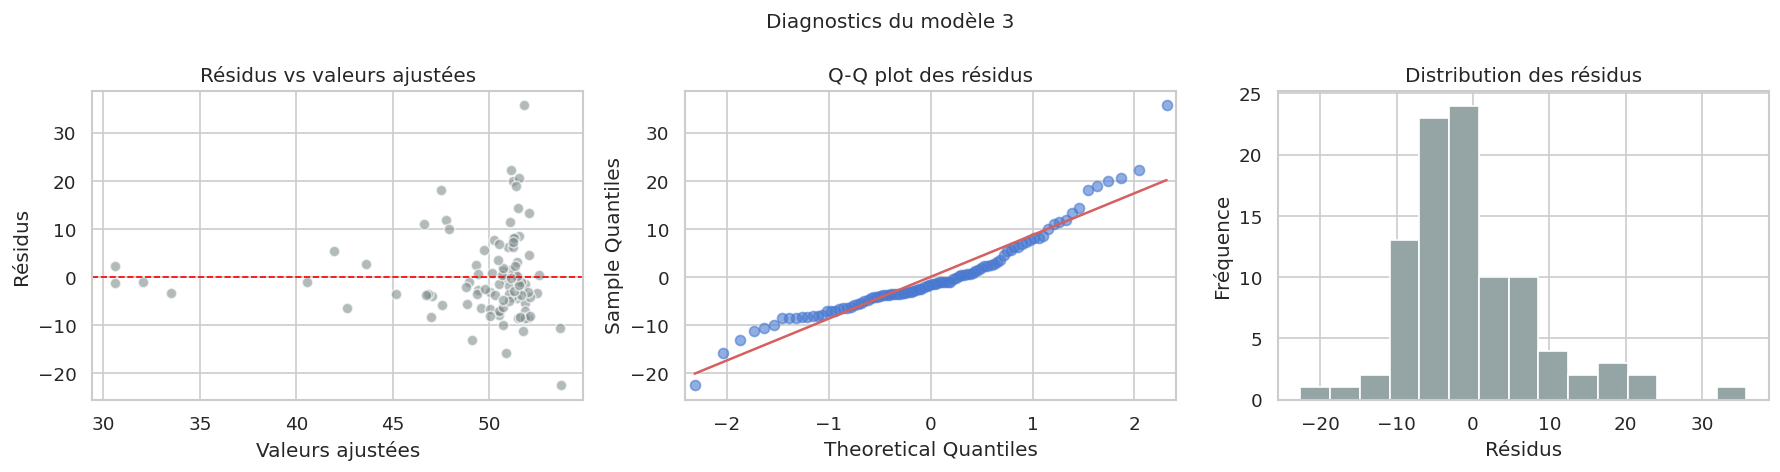

Test de Shapiro-Wilk : W = 0.9225, p = 0.0000
→ Les résidus s'écartent significativement de la normale (p < 0.05) — interpréter avec prudence


In [ ]:
import numpy as np
from scipy.stats import shapiro

residus = mod3.resid
fitted  = mod3.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Résidus vs valeurs ajustées (homoscédasticité)
axes[0].scatter(fitted, residus, alpha=0.6, color="#7f8c8d", edgecolors="white", s=40)
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_xlabel("Valeurs ajustées")
axes[0].set_ylabel("Résidus")
axes[0].set_title("Résidus vs valeurs ajustées")

# 2. Q-Q plot (normalité)
sm.qqplot(residus, line="s", ax=axes[1], alpha=0.6)
axes[1].set_title("Q-Q plot des résidus")

# 3. Distribution des résidus
axes[2].hist(residus, bins=15, color="#95a5a6", edgecolor="white")
axes[2].set_xlabel("Résidus")
axes[2].set_ylabel("Fréquence")
axes[2].set_title("Distribution des résidus")

plt.suptitle("Diagnostics du modèle 3", fontsize=12)
plt.tight_layout()
plt.show()

# Test de Shapiro-Wilk
stat, p_sw = shapiro(residus)
print(f"Test de Shapiro-Wilk : W = {stat:.4f}, p = {p_sw:.4f}")
if p_sw > 0.05:
    print("→ On ne rejette pas l'hypothèse de normalité des résidus (p > 0.05)")
else:
    print("→ Les résidus s'écartent significativement de la normale (p < 0.05) — interpréter avec prudence")

**Lecture des diagnostics :**
- *Résidus vs valeurs ajustées* : le nuage est globalement centré sur 0 
  mais quelques points extrêmes en haut à gauche (forts résidus positifs 
  pour les hauts taux de valorisation) signalent une légère 
  hétéroscédasticité.
- *Q-Q plot* : les queues s'écartent de la diagonale, surtout à droite — 
  quelques départements outliers (Vendée, Saône-et-Loire) tirent la 
  distribution vers le haut.
- *Shapiro-Wilk* : W = 0.9225, p < 0.001 → on rejette la normalité. Les 
  p-values et intervalles de confiance de la régression sont donc à 
  interpréter avec prudence. Une solution serait de tester une 
  transformation log du taux de valorisation ou d'utiliser des erreurs 
  standard robustes (HC3).

## 5. Conclusion générale

Cette étude avait pour objectif d'identifier les facteurs territoriaux et socio-économiques associés à la valorisation des déchets ménagers à l'échelle départementale en France.

**Principaux résultats :**

1. **La ruralité est positivement et significativement associée au taux de valorisation.** Cette relation se confirme à travers l'analyse descriptive, les corrélations, les cartes choroplèthes et la régression. Elle peut s'expliquer par une plus grande pratique du compostage et de la valorisation organique en milieu rural, ainsi qu'une moindre densité de déchets à gérer.

2. **Le niveau de vie médian n'est pas un déterminant significatif.** L'absence de relation entre revenu et valorisation suggère que les performances en matière de recyclage ne sont pas davantage le fait des territoires riches, mais qu'elles dépendent davantage de l'organisation territoriale.

3. **Le terme d'interaction n'est pas significatif** (p = 0.233) : l'effet 
de la ruralité sur la valorisation est indépendant du niveau de richesse 
du département. Les territoires ruraux pauvres et les territoires ruraux 
aisés valorisent leurs déchets dans des proportions similaires.



**Limites :**
- L'indicateur de ruralité n'est pas pondéré par la population, ce qui sur-représente les communes faiblement peuplées.
- Le modèle explique une part limitée de la variance (R² modéré) : d'autres facteurs (densité d'équipements, politiques locales, part de maisons individuelles avec jardin) mériteraient d'être intégrés.
- L'analyse est transversale (une seule année) : une approche longitudinale permettrait de contrôler des effets fixes départementaux.

**Pistes d'approfondissement :** intégration d'indicateurs de mobilité verte, de densité de déchèteries, ou de la part de logements individuels.